In [ ]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing   import OneHotEncoder, StandardScaler
from sklearn.cluster         import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics         import silhouette_score
from sklearn.decomposition   import PCA


In [3]:
# 2. Load & Inspect
df = pd.read_csv('UcdpPrioConflict_v24_1.csv')
print(df.shape)
display(df.head(), df.info())


(2686, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2686 entries, 0 to 2685
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   conflict_id           2686 non-null   int64  
 1   location              2686 non-null   object 
 2   side_a                2686 non-null   object 
 3   side_a_id             2686 non-null   object 
 4   side_a_2nd            436 non-null    object 
 5   side_b                2686 non-null   object 
 6   side_b_id             2686 non-null   object 
 7   side_b_2nd            137 non-null    object 
 8   incompatibility       2686 non-null   int64  
 9   territory_name        1511 non-null   object 
 10  year                  2686 non-null   int64  
 11  intensity_level       2686 non-null   int64  
 12  cumulative_intensity  2686 non-null   int64  
 13  type_of_conflict      2686 non-null   int64  
 14  start_date            2686 non-null   object 
 15  start_prec

,conflict_id,location,side_a,side_a_id,side_a_2nd,side_b,side_b_id,side_b_2nd,incompatibility,territory_name,...,ep_end,ep_end_date,ep_end_prec,gwno_a,gwno_a_2nd,gwno_b,gwno_b_2nd,gwno_loc,region,version
0,11342,India,Government of India,141,NaN,GNLA,1163,NaN,1,Garoland,...,1,2012-12-21,NaN,750,NaN,NaN,NaN,750,3,24.1
1,11342,India,Government of India,141,NaN,GNLA,1163,NaN,1,Garoland,...,1,2014-11-27,NaN,750,NaN,NaN,NaN,750,3,24.1
2,11343,"Egypt, Israel",Government of Egypt,117,NaN,Government of Israel,121,NaN,1,Suez/Sinai,...,1,1967-06-10,NaN,651,NaN,666,NaN,"651, 666",2,24.1
3,11343,"Egypt, Israel",Government of Egypt,117,NaN,Government of Israel,121,NaN,1,Suez/Sinai,...,0,NaN,NaN,651,NaN,666,NaN,"651, 666",2,24.1
4,11343,"Egypt, Israel",Government of Egypt,117,NaN,Government of Israel,121,NaN,1,Suez/Sinai,...,1,1970-08-07,NaN,651,NaN,666,NaN,"651, 666",2,24.1


None

In [4]:
# 1. Inspect the true column names
print(df.columns.tolist())


['conflict_id', 'location', 'side_a', 'side_a_id', 'side_a_2nd', 'side_b', 'side_b_id', 'side_b_2nd', 'incompatibility', 'territory_name', 'year', 'intensity_level', 'cumulative_intensity', 'type_of_conflict', 'start_date', 'start_prec', 'start_date2', 'start_prec2', 'ep_end', 'ep_end_date', 'ep_end_prec', 'gwno_a', 'gwno_a_2nd', 'gwno_b', 'gwno_b_2nd', 'gwno_loc', 'region', 'version']


In [5]:
# 3. Cleaning & Missing‑Value Handling

# Drop truly auxiliary/text & ID columns, but keep 'location'
drop_cols = [
    'conflict_id', 'side_a', 'side_a_id', 'side_a_2nd',
    'side_b', 'side_b_id', 'side_b_2nd', 'incompatibility',
    'territory_name', 'gwno_a', 'gwno_a_2nd', 'gwno_b',
    'gwno_b_2nd', 'gwno_loc', 'start_date', 'start_prec',
    'start_date2', 'start_prec2', 'ep_end', 'ep_end_date',
    'ep_end_prec', 'version', 'notes', 'source_narrative'
]
df = df.drop(columns=drop_cols, errors='ignore')

# Drop rows missing key model inputs
df = df.dropna(subset=['type_of_conflict', 'cumulative_intensity'])

# Ensure year is integer
df['year'] = df['year'].astype(int)

print("After cleaning:", df.shape)



After cleaning: (2686, 6)


In [6]:
# 4. Feature Engineering & Scaling

# 4.1 Numeric feature: cumulative_intensity
num_cols = ['cumulative_intensity']
scaler = StandardScaler()
X_num = pd.DataFrame(
    scaler.fit_transform(df[num_cols]),
    columns=num_cols,
    index=df.index
)

# 4.2 Categorical features: region, type_of_conflict, intensity_level
cat_cols = ['region', 'type_of_conflict', 'intensity_level']
ohe = OneHotEncoder(sparse=False, drop='first')
X_cat = pd.DataFrame(
    ohe.fit_transform(df[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=df.index
)

# 4.3 Combine
X = pd.concat([X_num, X_cat], axis=1)
print("Feature matrix shape:", X.shape)


Feature matrix shape: (2686, 15)


In [7]:
# 5. Train & Evaluate clustering models

results = {}
# K‑Means: K=3,5
for k in [3, 5]:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    results[f'KMeans_{k}'] = silhouette_score(X, labels)

# Agglomerative: Ward vs. Complete (n_clusters=5)
for link in ['ward','complete']:
    ac = AgglomerativeClustering(n_clusters=5, linkage=link)
    labels = ac.fit_predict(X)
    results[f'Agglomerative_{link}'] = silhouette_score(X, labels)

# DBSCAN: eps=0.5,1.0
for eps in [0.5, 1.0]:
    db = DBSCAN(eps=eps, min_samples=5)
    lab = db.fit_predict(X)
    mask = lab != -1
    if mask.sum()>0:
        results[f'DBSCAN_eps{eps}'] = silhouette_score(X[mask], lab[mask])
    else:
        results[f'DBSCAN_eps{eps}'] = np.nan

print("Silhouette scores:\n", results)


Silhouette scores:
 {'KMeans_3': 0.38367721095316604, 'KMeans_5': 0.48190990184100546, 'Agglomerative_ward': 0.47195150269493996, 'Agglomerative_complete': 0.4530254478128423, 'DBSCAN_eps0.5': 1.0, 'DBSCAN_eps1.0': 0.4768547883462942}


In [8]:
# 6. Final model: K‑Means with k=5
best_k = 5
final_km = KMeans(n_clusters=best_k, random_state=42)
df['cluster'] = final_km.fit_predict(X)

# 7. Cluster centroids
centroids = pd.DataFrame(final_km.cluster_centers_, columns=X.columns)
print("Centroids:\n", centroids.round(2))

# 8. Cluster sizes & sample preview
print("Cluster sizes:\n", df['cluster'].value_counts())
for i in range(best_k):
    subset = df[df['cluster']==i]
    print(f"\nSample from cluster {i}:")
    display(subset[['location','year','cumulative_intensity','type_of_conflict']].head(3))


Centroids:
    cumulative_intensity  region_1, 2  region_1, 2, 3, 5  region_1, 3  \
0                  0.63        -0.00               -0.0        -0.00   
1                 -1.59         0.00               -0.0         0.01   
2                  0.63        -0.00               -0.0        -0.00   
3                  0.63        -0.00               -0.0        -0.00   
4                  0.63         0.01                0.0        -0.00   

   region_1, 3, 5  region_1, 4  region_1, 5  region_2  region_3  region_4  \
0            -0.0         -0.0         -0.0      0.56      0.00      0.00   
1            -0.0         -0.0          0.0      0.11      0.37      0.37   
2            -0.0         -0.0         -0.0      0.00      0.00      1.00   
3            -0.0         -0.0         -0.0     -0.00      1.00     -0.00   
4             0.0          0.0         -0.0      0.16      0.20      0.49   

   region_5  type_of_conflict_2  type_of_conflict_3  type_of_conflict_4  \
0      0.30      

,location,year,cumulative_intensity,type_of_conflict
2,"Egypt, Israel",1967,1,2
3,"Egypt, Israel",1969,1,2
4,"Egypt, Israel",1970,1,2



Sample from cluster 1:


,location,year,cumulative_intensity,type_of_conflict
0,India,2012,0,3
1,India,2014,0,3
6,Sudan,2011,0,3



Sample from cluster 2:


,location,year,cumulative_intensity,type_of_conflict
9,South Sudan,2013,1,3
12,South Sudan,2016,1,3
13,South Sudan,2017,1,3



Sample from cluster 3:


,location,year,cumulative_intensity,type_of_conflict
51,Hyderabad,1947,1,3
52,Hyderabad,1948,1,3
98,Afghanistan,2022,1,3



Sample from cluster 4:


,location,year,cumulative_intensity,type_of_conflict
10,South Sudan,2014,1,4
11,South Sudan,2015,1,4
18,Libya,2011,1,4


d:\Anaconda3\envs\DataScience\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


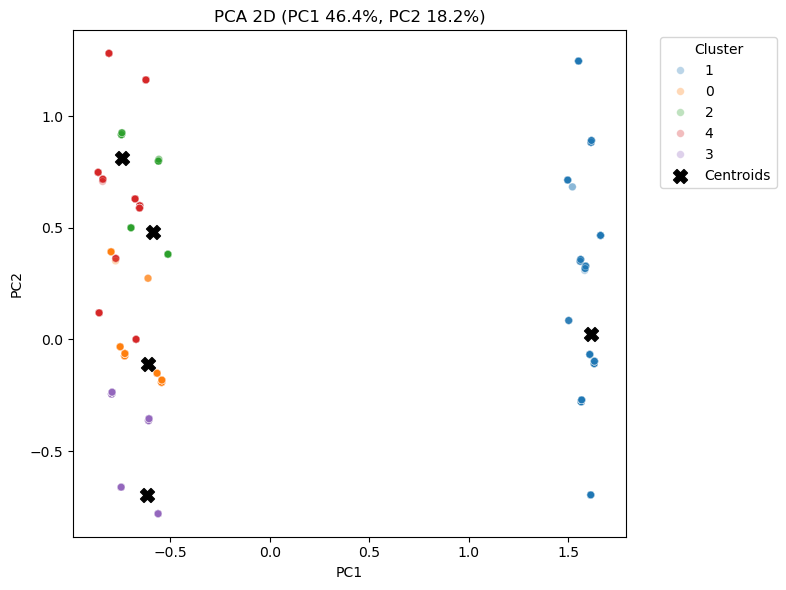

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Fit PCA to your feature matrix X (same one you clustered on)
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X)   # Z is now an (n_samples × 2) array

# 2) Plot the 2D scatter with centroids
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=Z[:,0], y=Z[:,1],
    hue=df['cluster'].astype(str),
    palette='tab10', s=30, alpha=0.3
)

# 3) (Optional) overlay the centroids
centroids_2d = pca.transform(final_km.cluster_centers_)
plt.scatter(
    centroids_2d[:,0], centroids_2d[:,1],
    c='black', marker='X', s=100, label='Centroids'
)

# 4) Annotate axes with explained variance
plt.title(f"PCA 2D (PC1 {pca.explained_variance_ratio_[0]:.1%}, "
          f"PC2 {pca.explained_variance_ratio_[1]:.1%})")
plt.xlabel("PC1"), plt.ylabel("PC2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()



d:\Anaconda3\envs\DataScience\lib\site-packages\sklearn\manifold\_t_sne.py:982: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


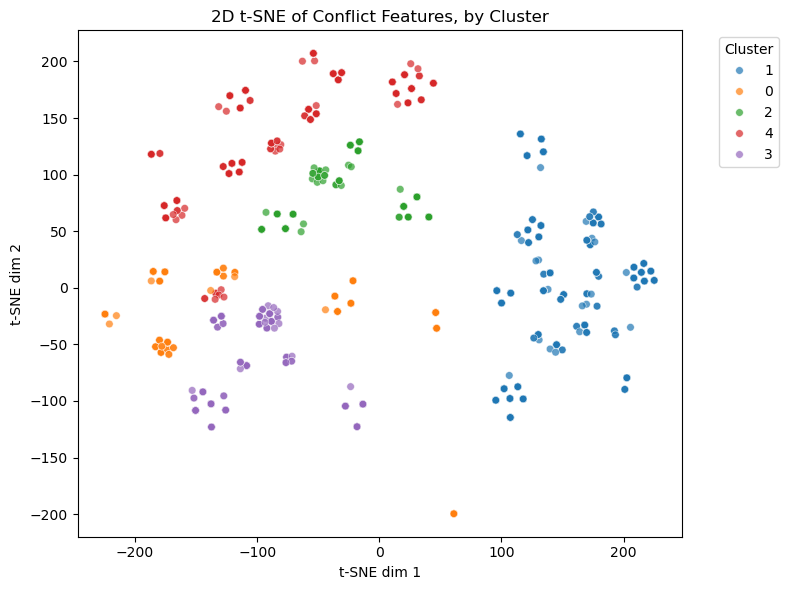

In [14]:
# 如果还没安装 t-SNE 相关依赖，通常 sklearn 自带，无需额外安装

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# 1) 用 t-SNE 降到 2 维
tsne = TSNE(
    n_components=2,
    perplexity=30,       # 根据样本数可调，一般 5—50
    learning_rate=200,   # 可尝试 100—1000
    n_iter=1000,
    random_state=42,
    init='pca'           # 初始化方式：'pca' 或 'random'
)
Z_tsne = tsne.fit_transform(X)

# 2) 绘制散点图
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=Z_tsne[:, 0], y=Z_tsne[:, 1],
    hue=df['cluster'].astype(str),
    palette='tab10',
    s=30, alpha=0.7
)
plt.title("2D t‑SNE of Conflict Features, by Cluster")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


d:\Anaconda3\envs\DataScience\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


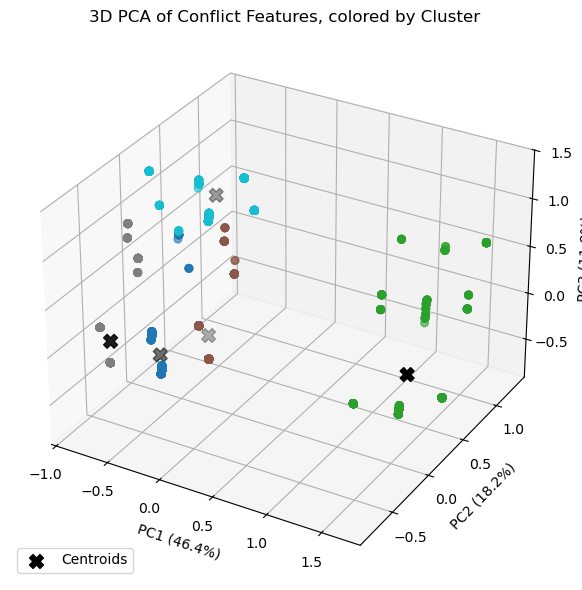

In [16]:
# 3D PCA Visualization of Clustered Conflict Data

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.decomposition import PCA

# 1) Fit PCA to 3 components
pca3 = PCA(n_components=3, random_state=42)
Z3 = pca3.fit_transform(X)  # X is your feature matrix

# 2) Create 3D scatter plot
fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    Z3[:, 0], Z3[:, 1], Z3[:, 2],
    c=df['cluster'],           # cluster labels
    cmap='tab10',
    s=30, alpha=0.6
)

# 3) Plot centroids in the same 3D PCA space
centroids_3d = pca3.transform(final_km.cluster_centers_)
ax.scatter(
    centroids_3d[:, 0], centroids_3d[:, 1], centroids_3d[:, 2],
    c='black', marker='X', s=100, label='Centroids'
)

# 4) Label axes with explained variance percentages
ax.set_xlabel(f"PC1 ({pca3.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca3.explained_variance_ratio_[1]:.1%})")
ax.set_zlabel(f"PC3 ({pca3.explained_variance_ratio_[2]:.1%})")

# 5) Legend and title
ax.set_title("3D PCA of Conflict Features, colored by Cluster")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster", 
                    loc='upper left', bbox_to_anchor=(1.05, 1))
ax.add_artist(legend1)
ax.legend(loc='lower left')

plt.tight_layout()
plt.show()
